# ME 280 Homework 2

I am going to start off by importing the necessary packages as opposed to importing them over and over again for every cell which I used to do.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import ultralytics
import json
import os

> Image Enhancement: With the given sudoku image in file (sudoku-original.png), using both CLAHE and Histogram Equalization methods. Compare the image before and after, for both methods, as well as the distribution of pixel values.

I used OpenCV for 3 years in highschool for the robotics team, but that was in Java. It will be interesting to see how the API pans out in a different languages. However, as it turns out, dealing with live camera feed is a lot different in Java as opposed to still images in Python so only the most basic knowledge of mine transferred over.

So I used http://opencv24-python-tutorials.readthedocs.io/ to its fullest extent and patched together a lot of tutorials.


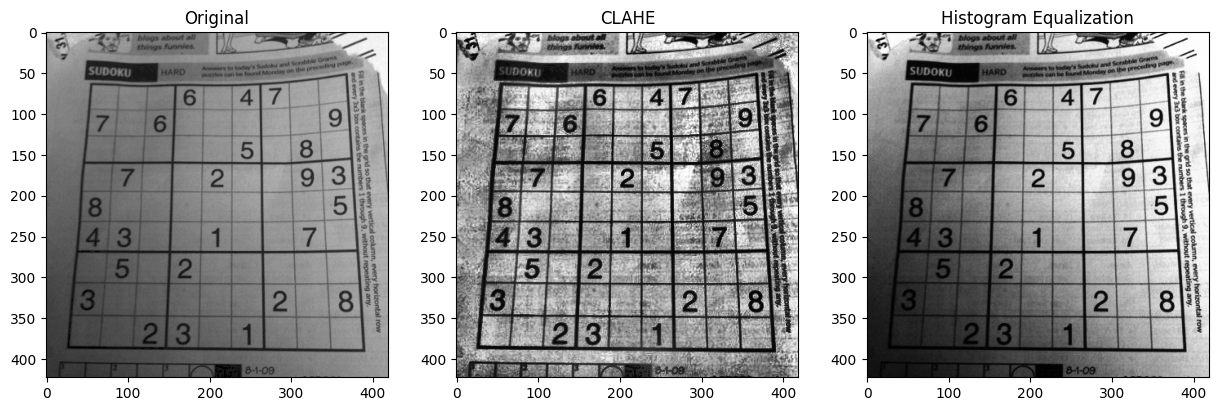

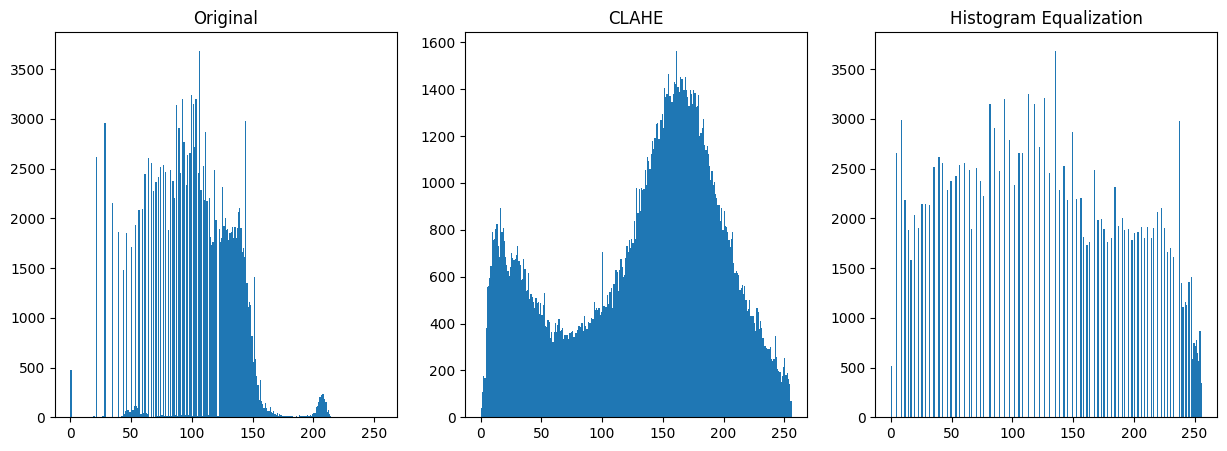

In [ ]:
# Paths are relative to the current file in Python, or at least this is the case in Jupyter
# notebooks which tripped me up since I use Node.JS a lot and that's working directory relative.
# Anyway, cv2 has imread which makes reading images trivial. the cv2.IMREAD_GRAYSCALE flag
# makes the image grayscale.
sudoku_original = cv2.imread(
    "../../perception/sudoku-original.png", cv2.IMREAD_GRAYSCALE
)

# I am not 100% sure what the value of clahe represents, perhaps it is a configuration object?
# Regardless, it acts like a class in the sense that after creating an instance of it, you can
# call methods on it like the apply function that we see below which accepts a single image in
# the form of a numpy array.
clahe = cv2.createCLAHE()
sudoku_clahe = clahe.apply(sudoku_original)

# Equalizing is even more trivial since cv2 has a built-in function for it.
sudoku_histogram_equalized = cv2.equalizeHist(sudoku_original)

# Displaying the images is far more involved than I first anticipated. I didn't want to write
# to disk and just show the images in the notebook so I use matplotlib's imshow function. But
# before I use that function, I declare a figure and an axes object. I chose a size of 5 for
# the individual images, of which I have 3, so I went with an overall size of 15x5.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# These functions are pretty straight forward. I did find it interesting that I have to set
# cmap explicitly to gray, otherwise it comes out all colorful for some reason? And of course
# the other methods are for setting the titles.
axes[0].imshow(sudoku_original, cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(sudoku_clahe, cmap="gray")
axes[1].set_title("CLAHE")
axes[2].imshow(sudoku_histogram_equalized, cmap="gray")
axes[2].set_title("Histogram Equalization")

# Show the plot.
plt.show()

# Another plot, but this time for the histograms. Same deal as before for the disk situation and
# the sizes. However, this time I use the hist function instead of imshow which accepts bins
# which, to the best of my understanding, controls the resolution of the histogram while the range
# is self explanatory.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(sudoku_original.ravel(), bins=256, range=(0, 256))
axes[0].set_title("Original")
axes[1].hist(sudoku_clahe.ravel(), bins=256, range=(0, 256))
axes[1].set_title("CLAHE")
axes[2].hist(sudoku_histogram_equalized.ravel(), bins=256, range=(0, 256))
axes[2].set_title("Histogram Equalization")

plt.show()

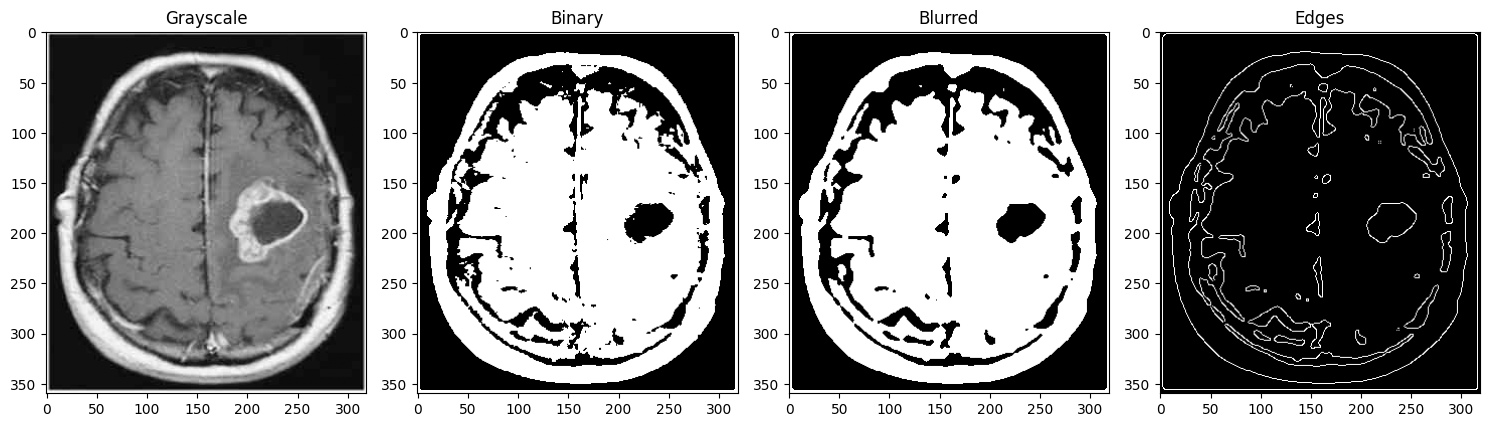

In [3]:
tumor = cv2.imread("../../perception/image_tumor.jpg")

gray = cv2.cvtColor(tumor, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
blurred = cv2.medianBlur(binary, 5)
edges = cv2.Canny(blurred, 0, 255)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale")

axes[1].imshow(binary, cmap="gray")
axes[1].set_title("Binary")

axes[2].imshow(blurred, cmap="gray")
axes[2].set_title("Blurred")

axes[3].imshow(edges, cmap="gray")
axes[3].set_title("Edges")

plt.tight_layout()
plt.show()

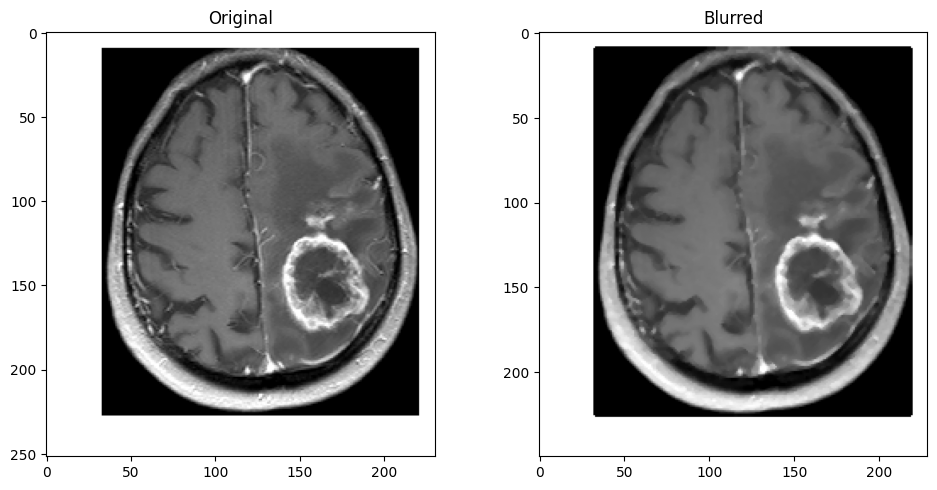

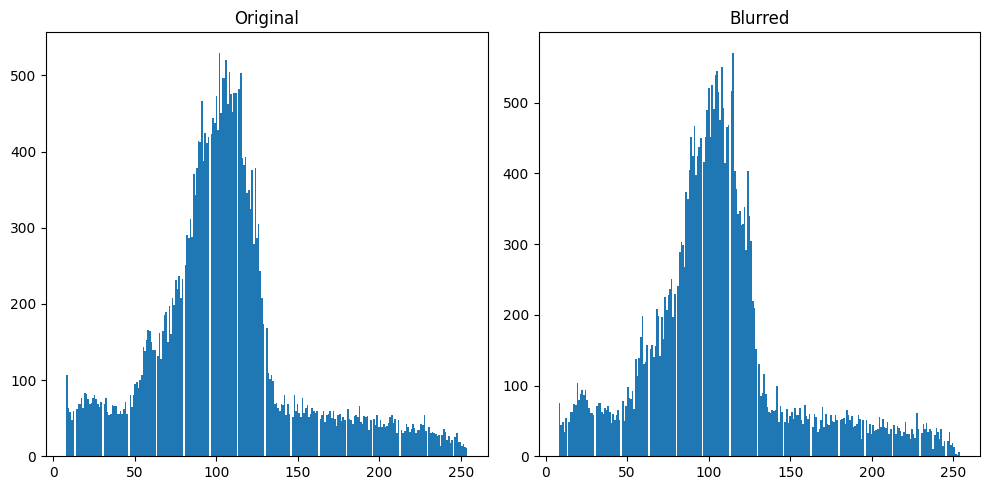

In [4]:
tumor = cv2.imread("../../perception/tumor-image.png")
gray = cv2.cvtColor(tumor, cv2.COLOR_BGR2GRAY)


def custom_blur(img):
    h, w = img.shape
    result = np.zeros((h - 2, w - 2))

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            patch = img[i - 1 : i + 2, j - 1 : j + 2]
            result[i - 1, j - 1] = np.median(patch)

    return result


custom_blurred = custom_blur(gray)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(custom_blurred, cmap="gray")
axes[1].set_title("Blurred")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

range_hack = (8, 254)
bins_hack = range_hack[1] - range_hack[0] + 1

axes[0].hist(gray.ravel(), bins=bins_hack, range=range_hack)
axes[0].set_title("Original")

axes[1].hist(custom_blurred.ravel(), bins=bins_hack, range=range_hack)
axes[1].set_title("Blurred")

plt.tight_layout()
plt.show()

In [5]:
def train(name: str, imgsz: int, pretrained: bool):
    return YOLO(f"{name}.yaml").train(
        data="../../perception/data.yaml",
        epochs=25,
        imgsz=imgsz,
        batch=2,
        pretrained=pretrained,
    )


def postmortem(report, name: str):
    print(f"P ({name}) =", report.results_dict["metrics/precision(B)"])
    print(f"R ({name}) =", report.results_dict["metrics/recall(B)"])
    print(f"mAP@0.5 ({name}) =", report.results_dict["metrics/mAP50(B)"], end="\n\n")

In [6]:
report_nano = train("yolo11n", 64, False)
report_small = train("yolo11s", 64, False)
report_medium = train("yolo11m", 64, False)
report_large = train("yolo11l", 64, False)

Ultralytics 8.3.221 🚀 Python-3.10.12 torch-2.9.0+cu128 CUDA:0 (GRID A100X-10C, 10236MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../perception/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

In [7]:
postmortem(report_nano, "nano")
postmortem(report_small, "small")
postmortem(report_medium, "medium")
postmortem(report_large, "large")

P (nano) = 0.22347881974425163
R (nano) = 0.06917537377870385
mAP@0.5 (nano) = 0.04893739485764279

P (small) = 0.2786021268742506
R (small) = 0.08109431664769569
mAP@0.5 (small) = 0.05940836827807052

P (medium) = 0.25972516100912807
R (medium) = 0.08641249336646006
mAP@0.5 (medium) = 0.05979845130965619

P (large) = 0.22805742316954752
R (large) = 0.08166911839781575
mAP@0.5 (large) = 0.05837376741298166



In [8]:
report_nano_128 = train("yolo11n", 128, False)
report_nano_256 = train("yolo11n", 256, False)
report_nano_512 = train("yolo11n", 512, False)

Ultralytics 8.3.221 🚀 Python-3.10.12 torch-2.9.0+cu128 CUDA:0 (GRID A100X-10C, 10236MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../perception/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=128, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

In [9]:
postmortem(report_nano, "nano 64px")
postmortem(report_nano_128, "nano 128px")
postmortem(report_nano_256, "nano 256px")
postmortem(report_nano_512, "nano 512px")

P (nano 64px) = 0.22347881974425163
R (nano 64px) = 0.06917537377870385
mAP@0.5 (nano 64px) = 0.04893739485764279

P (nano 128px) = 0.20641078068910185
R (nano 128px) = 0.10788877594021377
mAP@0.5 (nano 128px) = 0.06315802884359502

P (nano 256px) = 0.3308291380545722
R (nano 256px) = 0.19436082927757756
mAP@0.5 (nano 256px) = 0.15368465078427931

P (nano 512px) = 0.4918226009826939
R (nano 512px) = 0.3223256334221119
mAP@0.5 (nano 512px) = 0.33252710460314505



In [10]:
report_nano_pretrained = train("yolo11n", 64, True)
report_medium_pretrained = train("yolo11m", 64, True)
report_large_pretrained = train("yolo11l", 64, True)

Ultralytics 8.3.221 🚀 Python-3.10.12 torch-2.9.0+cu128 CUDA:0 (GRID A100X-10C, 10236MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../../perception/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

In [11]:
postmortem(report_nano, "nano")
postmortem(report_medium, "medium")
postmortem(report_large, "large")

postmortem(report_nano_pretrained, "nano pretrained")
postmortem(report_medium_pretrained, "medium pretrained")
postmortem(report_large_pretrained, "large pretrained")

P (nano) = 0.22347881974425163
R (nano) = 0.06917537377870385
mAP@0.5 (nano) = 0.04893739485764279

P (medium) = 0.25972516100912807
R (medium) = 0.08641249336646006
mAP@0.5 (medium) = 0.05979845130965619

P (large) = 0.22805742316954752
R (large) = 0.08166911839781575
mAP@0.5 (large) = 0.05837376741298166

P (nano pretrained) = 0.22347881974425163
R (nano pretrained) = 0.06917537377870385
mAP@0.5 (nano pretrained) = 0.04893739485764279

P (medium pretrained) = 0.25972516100912807
R (medium pretrained) = 0.08641249336646006
mAP@0.5 (medium pretrained) = 0.05979845130965619

P (large pretrained) = 0.22805742316954752
R (large pretrained) = 0.08166911839781575
mAP@0.5 (large pretrained) = 0.05837376741298166

